# Momentum Analysis

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from   matplotlib.lines import Line2D

In [2]:
note_path = os.getcwd()
repo_path = os.path.abspath(os.path.join(note_path, ".."))
data_path = os.path.join(repo_path, "data")
pic_path  = os.path.join(repo_path, "writeup", "pictures")

In [3]:
sys.path.append(os.path.join(repo_path, "src"))
from FactorExposureTools import FactorExposureTools

In [4]:
group_renamer_ = {
    'em_carry'        : "EM Carry", 
    'g10_carry'       : "G10 Carry", 
    'illiquid_future' : "ill Fut", 
    'liquid_future'   : "Liq Fut",
    "avg"             : "Average"}

vol_renamer_ = {
    "lagged"     : "Lagged",
    "perf"       : "Perfect",
    "none"       : "None",
    "perfect"    : "Perfect",
    "lag_vol_rtn": "Lagged",	
    "vol_rtn"    : "Perfect"}

sample_renamer_ = {
    "expanding"  : "Expanding",
    "full_sample": "Full Sample",
    "train_test" : "Train/Test",}

stat_renamer_ = {
    "coeff" : "Coefficient",
    "tvalue": r"$t$-value"}

port_renamer_ = {
    "ols_forecasted": "OLS For",	
    "ols_resid"     : "OLS Resid",	
    "opt_resid"     : "Opt Resid",	
    "opt_trend"     : "Opt Trend"}

backtest_renamer_ = {
    'SignalBacktests'     : "Signal", 
    'TrendSignalBacktests': "Trend Signal"}

renamer = {
    **group_renamer_, **backtest_renamer_,
    **vol_renamer_, **stat_renamer_, 
    **sample_renamer_, **port_renamer_}

FLOAT_FORMAT = lambda x: f"{x:.2f}"

In [5]:
path = r"C:\Users\Diego\Documents\GitHub\FXEquitySpillover\data\FXTickerGuide.xlsx"
df_ticker = (pd
    .read_excel(io = path, sheet_name = "TickerGuide")
    [["ticker", "group", "shorthand_name", "return_type"]]
    .rename(columns = {"ticker": "fx_ticker"}))

In [6]:
backtests     = ["SignalBacktests.parquet", "TrendSignalBacktests.parquet"]
backtest_path = os.path.join(data_path, "Backtests")
df_backtest_raw   = pd.concat([(pd
    .read_parquet(path = os.path.join(backtest_path, backtest))
    .assign(backtest = backtest.split(".")[0]))
    for backtest in backtests])

In [7]:
df_backtest_prep = (df_backtest_raw
    [["date", "etf_ticker", "fx_ticker", "country", "group", "shorthand_name", "backtest", "vol_rtn", "lag_vol_rtn"]]
    .melt(id_vars = ["date", "etf_ticker", "fx_ticker", "country", "group", "shorthand_name", "backtest"])
    .assign(variable = lambda x: np.where(x.variable == "vol_rtn", "perf", "lagged"))
    .rename(columns = {"value": "vol_rtn"}))

In [8]:
sig_path   = r"A:\GitHub\FXEquitySpillover\data\Signals"
spread_sig = os.path.join(sig_path, "ReturnSpreadSignal.parquet")
trend_sig  = os.path.join(sig_path, "ReturnTrendSpreadSignal.parquet")

df_spread = (pd
    .read_parquet(path = spread_sig)
    [["date", "ticker", "spread"]])

df_trend = (pd
    .read_parquet(path = trend_sig, engine = "pyarrow")
    [["date", "ticker", "signal"]])

In [9]:
df_tmp_ports = (df_backtest_prep
    [["date", "group", "backtest", "variable", "vol_rtn"]]
    .groupby(["date", "group", "backtest", "variable"])
    .agg("mean")
    .reset_index()
    .rename(columns = {"variable": "target"}))

df_avg = (df_tmp_ports
    .pivot(index = ["date", "backtest", "target"], columns = "group", values = "vol_rtn")
    .mean(axis = 1)
    .to_frame(name = "vol_rtn")
    .reset_index()
    .assign(group = "avg"))

df_ports = pd.concat([df_tmp_ports, df_avg])

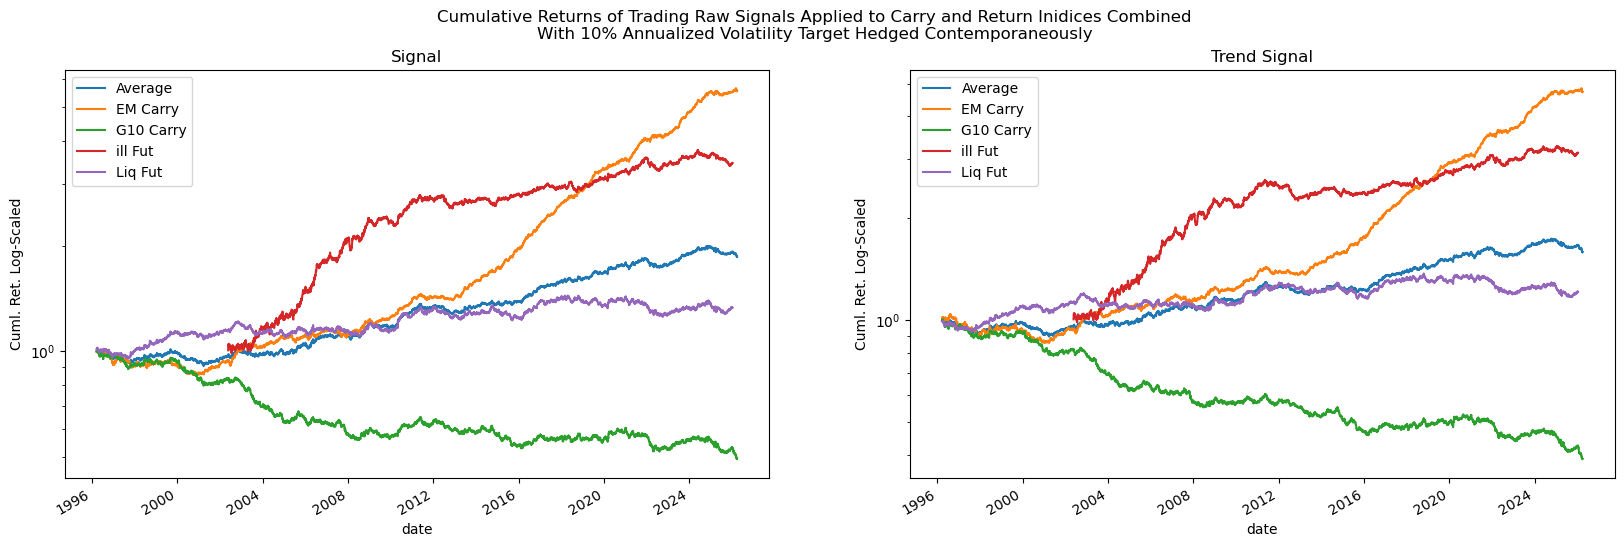

In [10]:
df_port_tmp = df_ports.loc[lambda x: x.target == "perf"]
backtests   = df_port_tmp.backtest.drop_duplicates().sort_values().to_list()
fig, axes   = plt.subplots(ncols = len(backtests), figsize = (20,6))

for backtest, ax in zip(backtests, axes.flatten()): 

    (df_port_tmp
        .loc[lambda x: x.backtest == backtest]
        .rename(columns = {"group": ""})
        .pivot(index = "date", columns = "", values = "vol_rtn")
        .rename(columns = renamer)
        .apply(lambda x: np.cumprod(1 + x))
        .plot(
            ax = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            logy   = True,
            title  = renamer[backtest.split(".")[0]]))

fig.suptitle("Cumulative Returns of Trading Raw Signals Applied to Carry and Return Inidices Combined\nWith 10% Annualized Volatility Target Hedged Contemporaneously\n")
fig.savefig(os.path.join(pic_path, "RawSignalBacktest.jpeg"), dpi = 300)
plt.show()

In [11]:
(df_port_tmp
    .pivot(index = ["date", "group"], columns = "backtest", values = "vol_rtn")
    .reset_index()
    .drop(columns = ["date"])
    .groupby(["group"])
    .agg("corr")
    .loc[lambda x: x.SignalBacktests != 1]
    [["SignalBacktests"]]
    .reset_index()
    .replace(renamer)
    .set_index("group")
    .drop(columns = ["backtest"])
    .rename(columns = {"SignalBacktests": "corr"})
    .T
    .reset_index(drop = True))

group,Average,EM Carry,G10 Carry,ill Fut,Liq Fut
0,0.943088,0.923052,0.928302,0.929903,0.93123


In [12]:
display(df_ports
    .drop(columns = ["date"])
    .groupby(["group", "backtest", "target"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(renamer)
    .rename(columns = {
        "backtest": "Backtest",
        "group"   : "Group",
        "target"  : ""})
    .pivot(index = ["Backtest", "Group"], columns = "", values = "vol_rtn")
    #.to_latex(float_format = FLOAT_FORMAT)
    )

Lagged   Perfect
Backtest     Group                        
Signal       Average    0.530678  0.558851
             EM Carry   1.428781  1.450870
             G10 Carry -0.427948 -0.428290
             Liq Fut    0.208943  0.236357
             ill Fut    0.823224  0.878200
Trend Signal Average    0.427830  0.421631
             EM Carry   1.294258  1.309574
             G10 Carry -0.551661 -0.582482
             Liq Fut    0.182568  0.166926
             ill Fut    0.768926  0.808349

In [13]:
path = r"C:\Users\Diego\Documents\GitHub\FXEquitySpillover\data\FactorAnalysis\ReturnsDifferentialTrendOLSModels.pkl"
with open(path, "rb") as f: models = pickle.load(f)

In [14]:
tmp_keys = [
    key for key in models.keys()
    if key.split("-")[-1] == "with_lag"]

In [15]:
df_lists = []

for tmp_key in tmp_keys: 

    tmp_model = models[tmp_key]
    df_param  = tmp_model.params.to_frame(name = "coeff").reset_index()
    df_tvalue = tmp_model.tvalues.to_frame(name = "tvalue").reset_index()
    
    df_add = (df_param
        .merge(right = df_tvalue, how = "inner", on = ["index"])
        .rename(columns = {"index": "param"})
        .assign(name = tmp_key))

    df_lists.append(df_add)

df_params = (pd.concat(df_lists))

In [16]:
df_param_tmp = (df_params
    .loc[lambda x: x.param == "signal"]
    .assign(
        str_split  = lambda x: x.name.str.split("-"),
        etf_ticker = lambda x: x.str_split.str[0],
        fx_ticker  = lambda x: x.str_split.str[1],
        vol_target = lambda x: x.str_split.str[2])
    .drop(columns = ["name", "str_split"]))

In [17]:
df_sharpe = (df_backtest_prep
    .loc[lambda x: x.backtest == "TrendSignalBacktests"]
    .loc[lambda x: x.variable == "perf"]
    [["fx_ticker", "vol_rtn"]]
    .groupby("fx_ticker")
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .rename(columns = {"vol_rtn": "sharpe"}))

In [18]:
df_compare = (df_param_tmp
    [["coeff", "tvalue", "fx_ticker", "vol_target"]]
    .merge(right = df_sharpe, how = "inner", on = ["fx_ticker"])
    .melt(id_vars = ["fx_ticker", "vol_target", "sharpe"])
    .assign(value = lambda x: x.value.abs()))

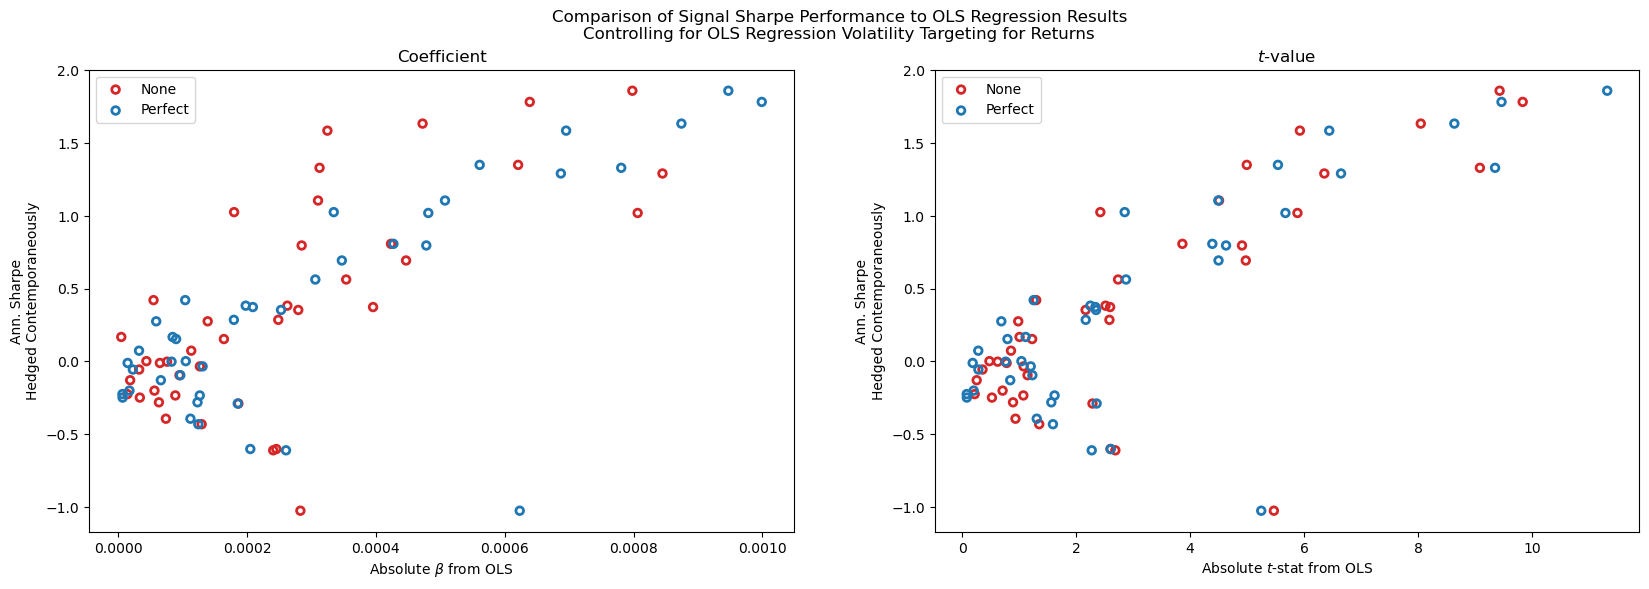

In [19]:
variables = df_compare.variable.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(variables), figsize = (20,6))

colorer = {
    "perfect": "tab:blue",
    "none"   : "tab:red"}

xlabel_renamer = {
    "coeff" : r"Absolute $\beta$ from OLS",
    "tvalue": r"Absolute $t$-stat from OLS"}

for variable, ax in zip(variables, axes.flatten()):

    df_tmp = (df_compare
        .loc[lambda x: x.variable == variable]
        .loc[lambda x: x.vol_target != "lagged"])

    vol_targets = df_tmp.vol_target.drop_duplicates().sort_values().to_list()
    for vol_target in vol_targets:

        df_plot = df_tmp.loc[lambda x: x.vol_target == vol_target]
        
        (ax
            .scatter( 
                x          = df_plot.value,
                y          = df_plot.sharpe,
                facecolors = "none",                  
                edgecolors = colorer[vol_target],
                s          = 30,
                linewidth  = 2,
                label      = renamer[vol_target]))

        
    ax.set_ylabel("Ann. Sharpe\nHedged Contemporaneously")
    ax.set_xlabel(xlabel_renamer[variable])
    ax.set_title(renamer[variable])
    ax.legend()

fig.suptitle("Comparison of Signal Sharpe Performance to OLS Regression Results\nControlling for OLS Regression Volatility Targeting for Returns")
plt.show()

In [20]:
path = r"C:\Users\Diego\Documents\GitHub\FXEquitySpillover\data\Backtests\ForecastedBacktest.parquet"
df_for_ports =  (pd
    .read_parquet(path = path, engine = "pyarrow")
    .merge(right = df_ticker, how = "inner", on = ["fx_ticker"])
    [["date", "regression", "fx_ticker", "lag_vol_rtn", "vol_rtn", "group"]]
    .melt(id_vars = ["date", "regression", "fx_ticker", "group"])
    .drop(columns = ["fx_ticker"])
    .groupby(["date", "regression", "variable", "group"])
    .agg("mean")
    .reset_index())

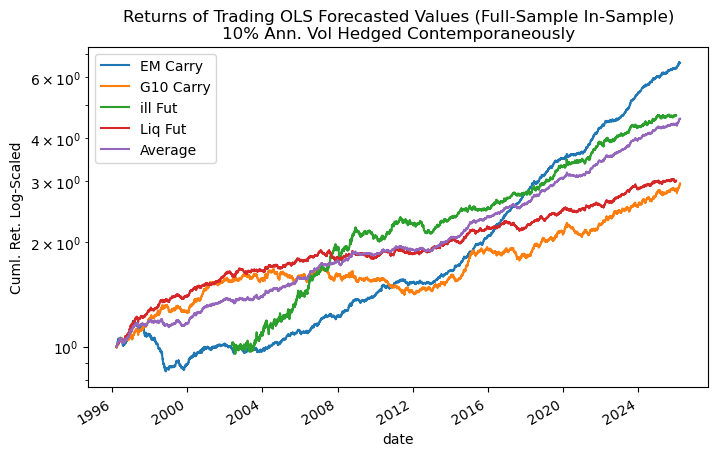

In [21]:
fig, axes = plt.subplots(figsize = (8,5))

(df_for_ports
    .loc[lambda x: x.variable == "vol_rtn"]
    .loc[lambda x: x.regression == "full_sample"]
    .rename(columns = {"group": ""})
    .pivot(index = "date", columns = "", values = "value")
    .assign(avg = lambda x: x.mean(axis = 1))
    .rename(columns = renamer)
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        ax     = axes,
        logy   = True,
        ylabel = "Cuml. Ret. Log-Scaled",
        title  = "Returns of Trading OLS Forecasted Values (Full-Sample In-Sample)\n10% Ann. Vol Hedged Contemporaneously"))

#fig.savefig(os.path.join(pic_path, "OLSForecastedISReturn.jpeg"), dpi = 300)
plt.show()

In [22]:
display(df_for_ports
    .pivot(index = ["date", "regression", "variable"], columns = "group", values = "value")
    .assign(avg = lambda x: x.mean(axis = 1))
    .reset_index()
    .melt(id_vars = ["date", "regression", "variable"])
    .drop(columns = ["date"])
    .groupby(["regression", "variable", "group"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(renamer)
    .rename(columns = {
        "regression": "",
        "variable"  : "Vol. Target",
        "group"     : "Group"})
    .pivot(index = "Group", columns = ["", "Vol. Target"], values = "value"))

Expanding           Full Sample           Train/Test          
Vol. Target    Lagged   Perfect      Lagged   Perfect     Lagged   Perfect
Group                                                                     
Average      1.304879  1.337006    1.756336  1.848095   2.071176  2.174070
EM Carry     1.527345  1.555133    1.649628  1.742069   1.774655  1.870585
G10 Carry    0.219373  0.249635    0.719365  0.756759   0.836389  0.885048
Liq Fut      0.356829  0.352389    1.052724  1.132248   1.081742  1.165879
ill Fut      0.973726  1.000683    1.063670  1.086661   1.080340  1.089671

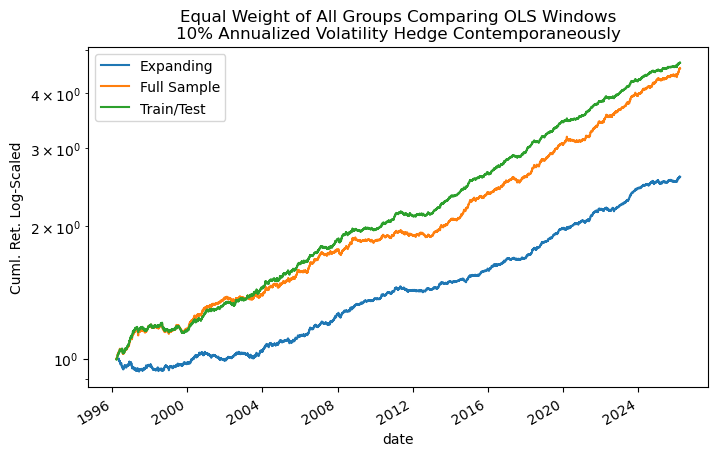

In [23]:
fig, axes = plt.subplots(figsize = (8,5))

df_for_regress_compare = (df_for_ports
    .loc[lambda x: x.variable == "vol_rtn"]
    .drop(columns = ["variable", "group"])
    .dropna()
    .groupby(["date", "regression"])
    .agg("mean")
    .reset_index())

(df_for_regress_compare
    .rename(columns = {"regression": ""})
    .pivot(index = "date", columns = "", values = "value")
    .rename(columns = renamer)
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        ax     = axes,
        logy   = True,
        ylabel = "Cuml. Ret. Log-Scaled",
        title  = "Equal Weight of All Groups Comparing OLS Windows\n10% Annualized Volatility Hedge Contemporaneously"))

fig.savefig(os.path.join(pic_path, "SampleOLSForecastBacktest.jpeg"), dpi = 300)
plt.show()

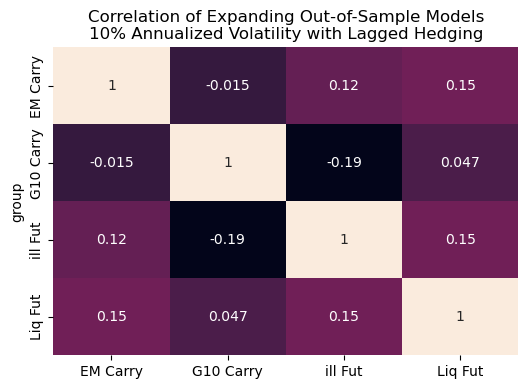

In [24]:
fig, axes = plt.subplots(figsize = (6,4))

df_corr = (df_for_ports
    .loc[lambda x: x.variable == "lag_vol_rtn"]
    .loc[lambda x: x.regression == "expanding"]
    .pivot(index = "date", columns = "group", values = "value")
    .rename(columns = renamer)
    .corr())

sns.heatmap(
    data  = df_corr, 
    ax    = axes,
    annot = True,
    cbar  = False)

axes.set_xlabel(""); ax.set_ylabel("")
axes.set_title("Correlation of Expanding Out-of-Sample Models\n10% Annualized Volatility with Lagged Hedging")
fig.savefig(os.path.join(pic_path, "CorrMatrixExpanding.jpeg"), dpi = 300)
plt.show()

In [25]:
path = r"C:\Users\Diego\Documents\GitHub\FXEquitySpillover\data\Backtests\ResidualBacktest.parquet"
df_resid_port = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .merge(right = df_ticker, how = "inner", on = ["fx_ticker"])
    [["date", "fx_ticker", "regression", "vol_rtn", "lag_vol_rtn", "group"]]
    .melt(id_vars = ["date", "fx_ticker", "regression", "group"])
    .drop(columns = ["fx_ticker"])
    .groupby(["date", "regression", "group", "variable"])
    .agg("mean")
    .reset_index())

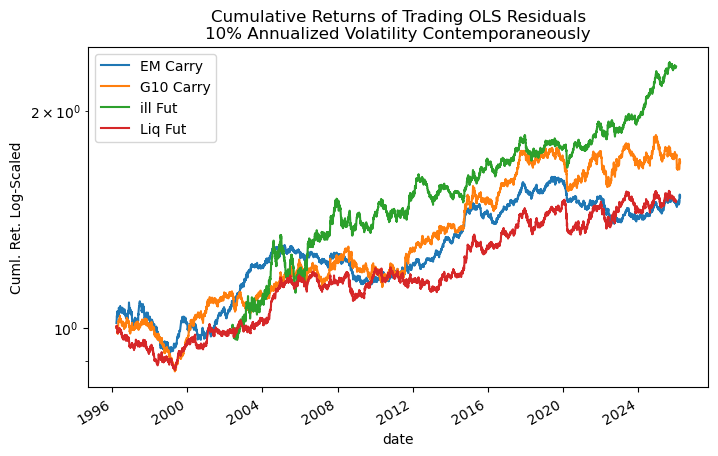

In [26]:
fig, axes = plt.subplots(figsize = (8,5))

(df_resid_port
    .loc[lambda x: x.variable == "vol_rtn"]
    .loc[lambda x: x.regression == "full_sample"]
    .rename(columns = {"group": ""})
    .pivot(index = "date", columns = "", values = "value")
    .rename(columns = renamer)
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        logy   = True,
        ax     = axes,
        ylabel = "Cuml. Ret. Log-Scaled",
        title  = "Cumulative Returns of Trading OLS Residuals\n10% Annualized Volatility Contemporaneously"))

#fig.savefig(os.path.join(pic_path, "OLSResidBacktest.jpeg"), dpi = 300)
plt.show()

In [27]:
display(df_resid_port
    .pivot(index = ["date", "regression", "variable"], columns = "group", values = "value")
    .assign(avg = lambda x: x.mean(axis = 1))
    .reset_index()
    .melt(id_vars = ["date", "regression", "variable"])
    .drop(columns = ["date"])
    .groupby(["regression", "variable", "group"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(renamer)
    .rename(columns = {
        "regression": "",
        "variable"  : "Vol. Target",
        "group"     : "Group"})
    .pivot(index = "Group", columns = ["", "Vol. Target"], values = "value"))

Expanding           Full Sample           Train/Test          
Vol. Target    Lagged   Perfect      Lagged   Perfect     Lagged   Perfect
Group                                                                     
Average      0.528581  0.603360    0.475028  0.515424   0.459455  0.497664
EM Carry     0.682445  0.779561    0.323040  0.371950   0.468806  0.535017
G10 Carry    0.293311  0.342662    0.329537  0.348977   0.257054  0.270954
Liq Fut      0.209500  0.237244    0.295521  0.311230   0.202057  0.216342
ill Fut      0.535650  0.602715    0.538779  0.592291   0.605709  0.646290

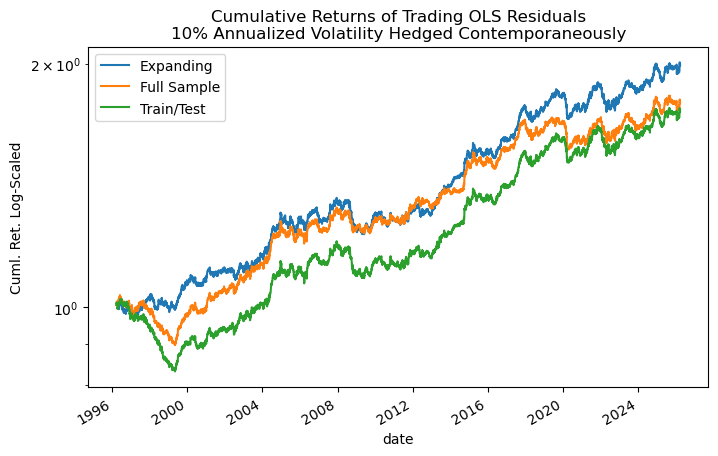

In [28]:
fig, axes = plt.subplots(figsize = (8,5))

df_resid_regress_compare = (df_resid_port
    .loc[lambda x: x.variable == "vol_rtn"]
    .drop(columns = ["variable", "group"])
    .dropna()
    .groupby(["date", "regression"])
    .agg("mean")
    .reset_index())

(df_resid_regress_compare
    .rename(columns = {"regression": ""})
    .pivot(index = "date", columns = "", values = "value")
    .rename(columns = renamer)
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        ax      = axes,
        ylabel = "Cuml. Ret. Log-Scaled",
        logy   = True,
        title  = "Cumulative Returns of Trading OLS Residuals\n10% Annualized Volatility Hedged Contemporaneously"))

#fig.savefig(os.path.join(pic_path, "EqualWeightResidBacktest.jpeg"), dpi = 300)
plt.show()

In [29]:
df_combined = (df_for_regress_compare
    .rename(columns = {"value": "for_rtn"})
    .merge(right = df_resid_regress_compare, how = "inner", on = ["date", "regression"])
    .rename(columns = {"value": "resid_rtn"}))

In [30]:
(df_combined
    .drop(columns = ["date"])
    .groupby("regression")
    .agg("corr")
    .reset_index()
    .loc[lambda x: x.resid_rtn != 1]
    .set_index("regression")
    [["resid_rtn"]]
    .T
    .reset_index(drop = True))

regression,expanding,full_sample,train_test
0,-0.04669,-0.005365,0.006175


In [31]:
(df_combined
    .set_index(["date", "regression"])
    .assign(avg = lambda x: x.mean(axis = 1))
    .reset_index()
    .melt(id_vars = ["date", "regression"])
    .drop(columns = ["date"])
    .groupby(["regression", "variable"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(renamer)
    .replace({
        "for_rtn"  : "Forecasted Strat",
        "resid_rtn": "Resid Strat"})
    .pivot(index = "regression", columns = "variable", values = "value")
    [["Forecasted Strat", "Resid Strat", "Average"]])

variable,Forecasted Strat,Resid Strat,Average
regression,,,
Expanding,1.337006,0.603360,1.234444
Full Sample,1.848095,0.515424,1.487680
Train/Test,2.174070,0.497664,1.553496


# Optimized Signal

In [32]:
path = r"C:\Users\Diego\Documents\GitHub\FXEquitySpillover\data\Backtests\OptimizedTrendBacktest.parquet"
df_opt_trend = (pd
    .read_parquet(path = path, engine = "pyarrow")
    [["date", "fx_ticker", "group", "optimization", "sample_group", "vol_rtn", "lag_vol_rtn"]])

In [33]:
df_trend_group_port = (df_opt_trend
    [["date", "group", "optimization", "vol_rtn", "lag_vol_rtn"]]
    .melt(id_vars = ["date", "group", "optimization"])
    .groupby(["date", "group", "optimization", "variable"])
    .agg("mean")
    .reset_index())

In [34]:
groups  = df_trend_group_port.group.drop_duplicates().sort_values().to_list()
df_plot = (df_trend_group_port
    .loc[lambda x: x.variable == "vol_rtn"]
    .dropna()
    .drop(columns = ["variable"]))

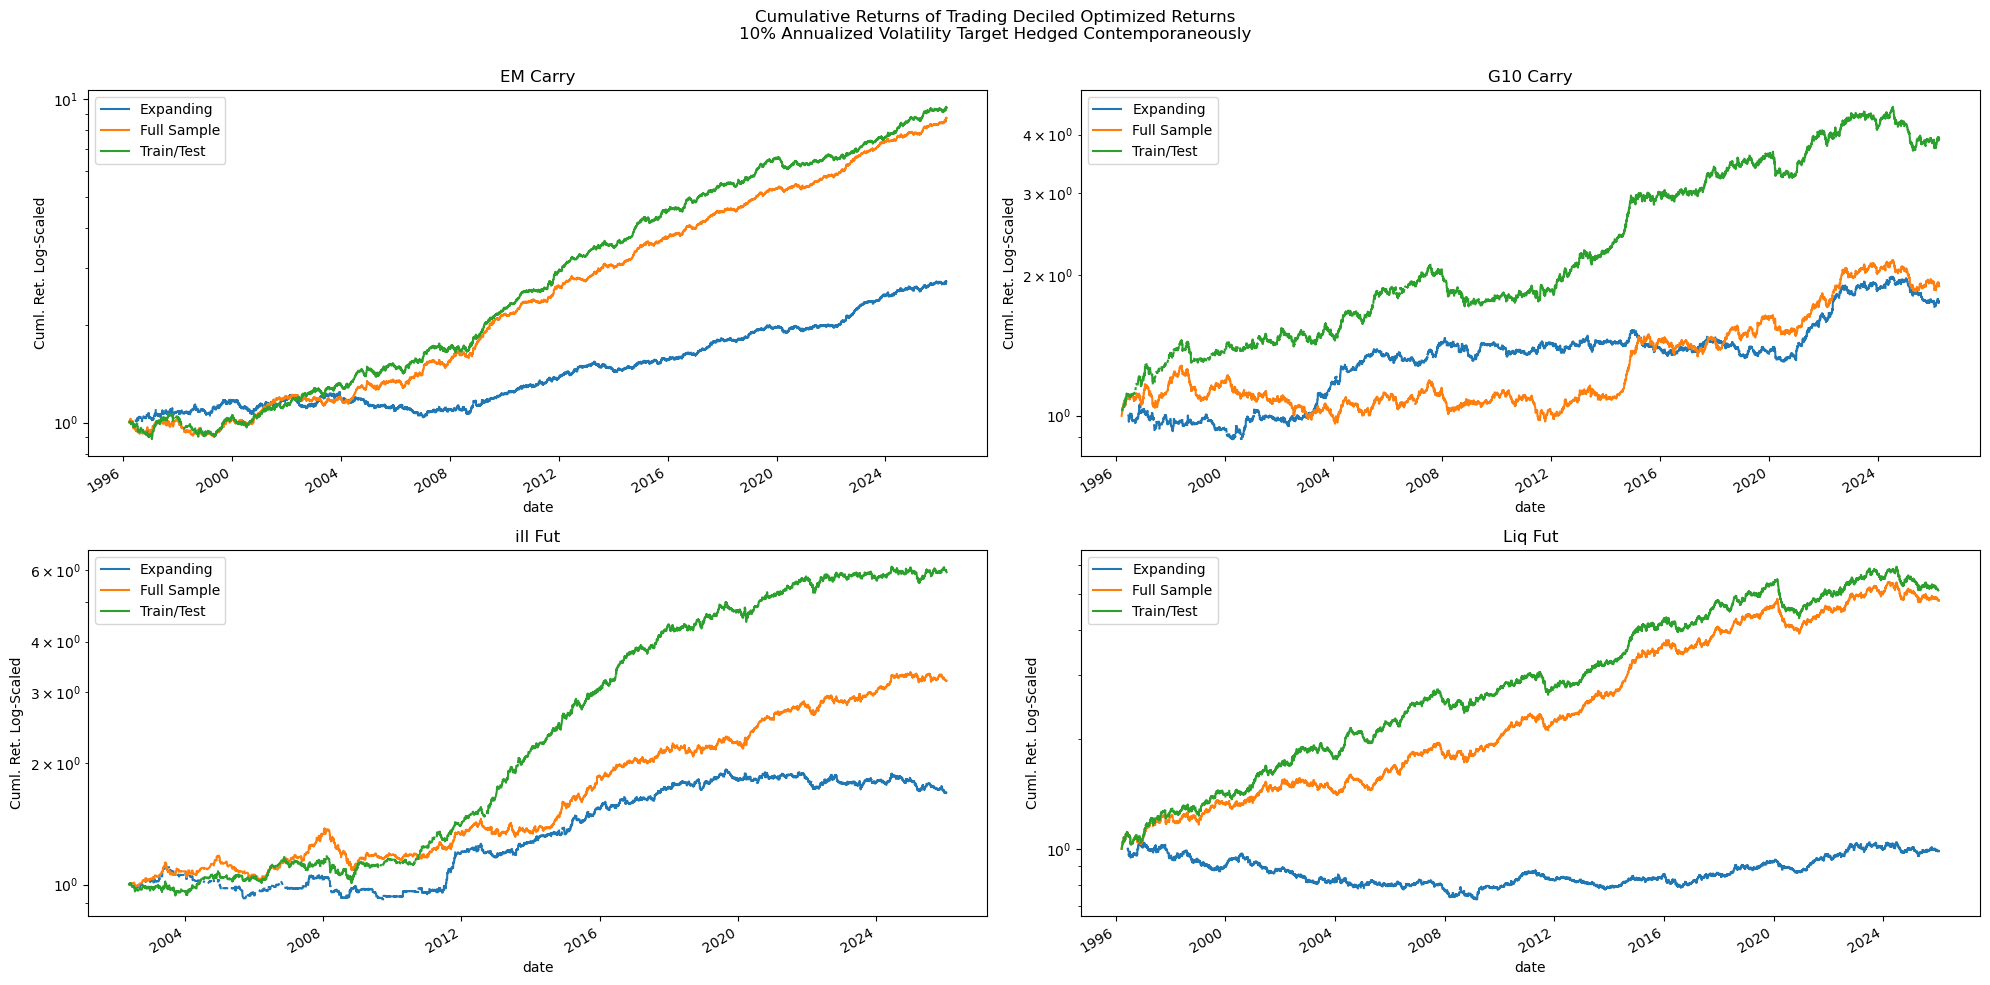

In [53]:
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

for group, ax in zip(groups, axes.flatten()):

    (df_plot
        .loc[lambda x: x.group == group]
        .rename(columns = {"optimization": ""})
        .pivot(index = "date", columns = "", values = "value")
        .apply(lambda x: np.cumprod(1 + x))
        .rename(columns = renamer)
        .rename(columns = {"in_sample": "Full-Sample"})
        .plot(
            ax    = ax,
            logy  = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = renamer[group]))

fig.suptitle("Cumulative Returns of Trading Deciled Optimized Returns\n10% Annualized Volatility Target Hedged Contemporaneously\n")
plt.tight_layout()
fig.savefig(os.path.join(pic_path, "DeciledOptimizedSignalBacktest.jpeg"))
plt.show()

In [56]:
display(df_trend_group_port
    .drop(columns = ["date"])
    .dropna()
    .groupby(["group", "optimization", "variable"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(renamer)
    .rename(columns = {
        "group"       : "Group",
        "variable"    : "Vol. Target", 
        "optimization": ""})
    .pivot(index  = "Group", columns = ["", "Vol. Target"], values = "value"))

Expanding           in_sample           Train/Test          
Vol. Target    Lagged   Perfect    Lagged   Perfect     Lagged   Perfect
Group                                                                   
EM Carry     1.142577  1.361449  1.722750  1.779139   1.765539  1.766112
G10 Carry    0.489620  0.543631  0.834664  0.837012   0.730892  0.749330
Liq Fut      0.413210  0.583493  0.987489  1.045119   1.079352  1.142372
ill Fut      1.222073  1.294074  1.199651  1.191729   1.009134  1.057340

In [37]:
df_port = (df_opt_trend[
    ["date", "fx_ticker", "optimization", "vol_rtn", "lag_vol_rtn"]]
    .melt(id_vars = ["date", "fx_ticker", "optimization"])
    .dropna()
    .drop(columns = ["fx_ticker"])
    .groupby(["date", "optimization", "variable"])
    .agg("mean")
    .reset_index())

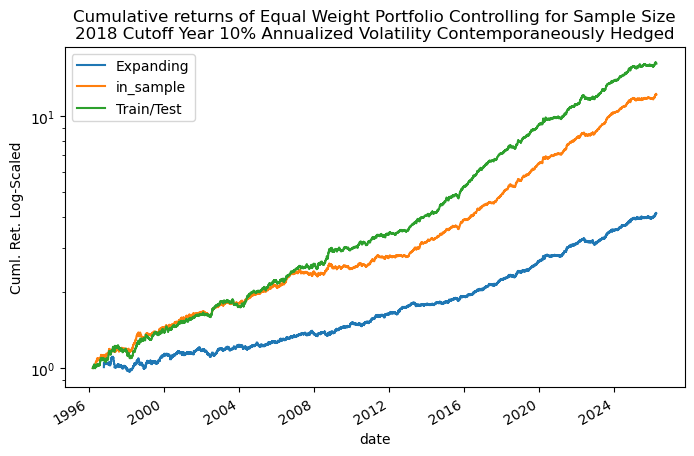

In [58]:
fig, axes = plt.subplots(figsize = (8,5))

(df_port
    .loc[lambda x: x.variable == "vol_rtn"]
    .rename(columns = {"optimization": ""})
    .pivot(index = "date", columns = "", values = "value")
    .apply(lambda x: np.cumprod(1 +x))
    .rename(columns = renamer)
    .plot(
        logy = True,
        ylabel = "Cuml. Ret. Log-Scaled", 
        ax     = axes,
        title  = "Cumulative returns of Equal Weight Portfolio Controlling for Sample Size\n2018 Cutoff Year 10% Annualized Volatility Contemporaneously Hedged"))

#fig.savefig(os.path.join(pic_path, "DecileSamplePort.jpeg"), dpi = 300)
plt.show()

In [61]:
display(df_port
    .drop(columns = ["date"])
    .groupby(["optimization", "variable"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(renamer)
    .rename(columns = {
        "optimization": "Optimization",
        "variable"    : ""})
    .pivot(index = "Optimization", columns = "", values = "value"))

,Lagged,Perfect
Optimization,,
Expanding,1.222833,1.429291
Train/Test,1.814033,1.857125
in_sample,1.968644,2.008774


In [40]:
path = r"C:\Users\Diego\Documents\GitHub\FXEquitySpillover\data\Backtests\OptimizedResidualBacktest.parquet"
df_opt_resid = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .merge(right = df_ticker, how = "inner", on = ["fx_ticker"])
    [["optimization", "fx_ticker", "date", "group", "vol_rtn", "lag_vol_rtn"]])

In [41]:
df_opt_resid_group = (df_opt_resid
    .melt(id_vars = ["date", "optimization", "fx_ticker", "group"])
    .dropna()
    .drop(columns = ["fx_ticker"])
    .groupby(["date", "optimization", "group", "variable"])
    .agg("mean")
    .reset_index())

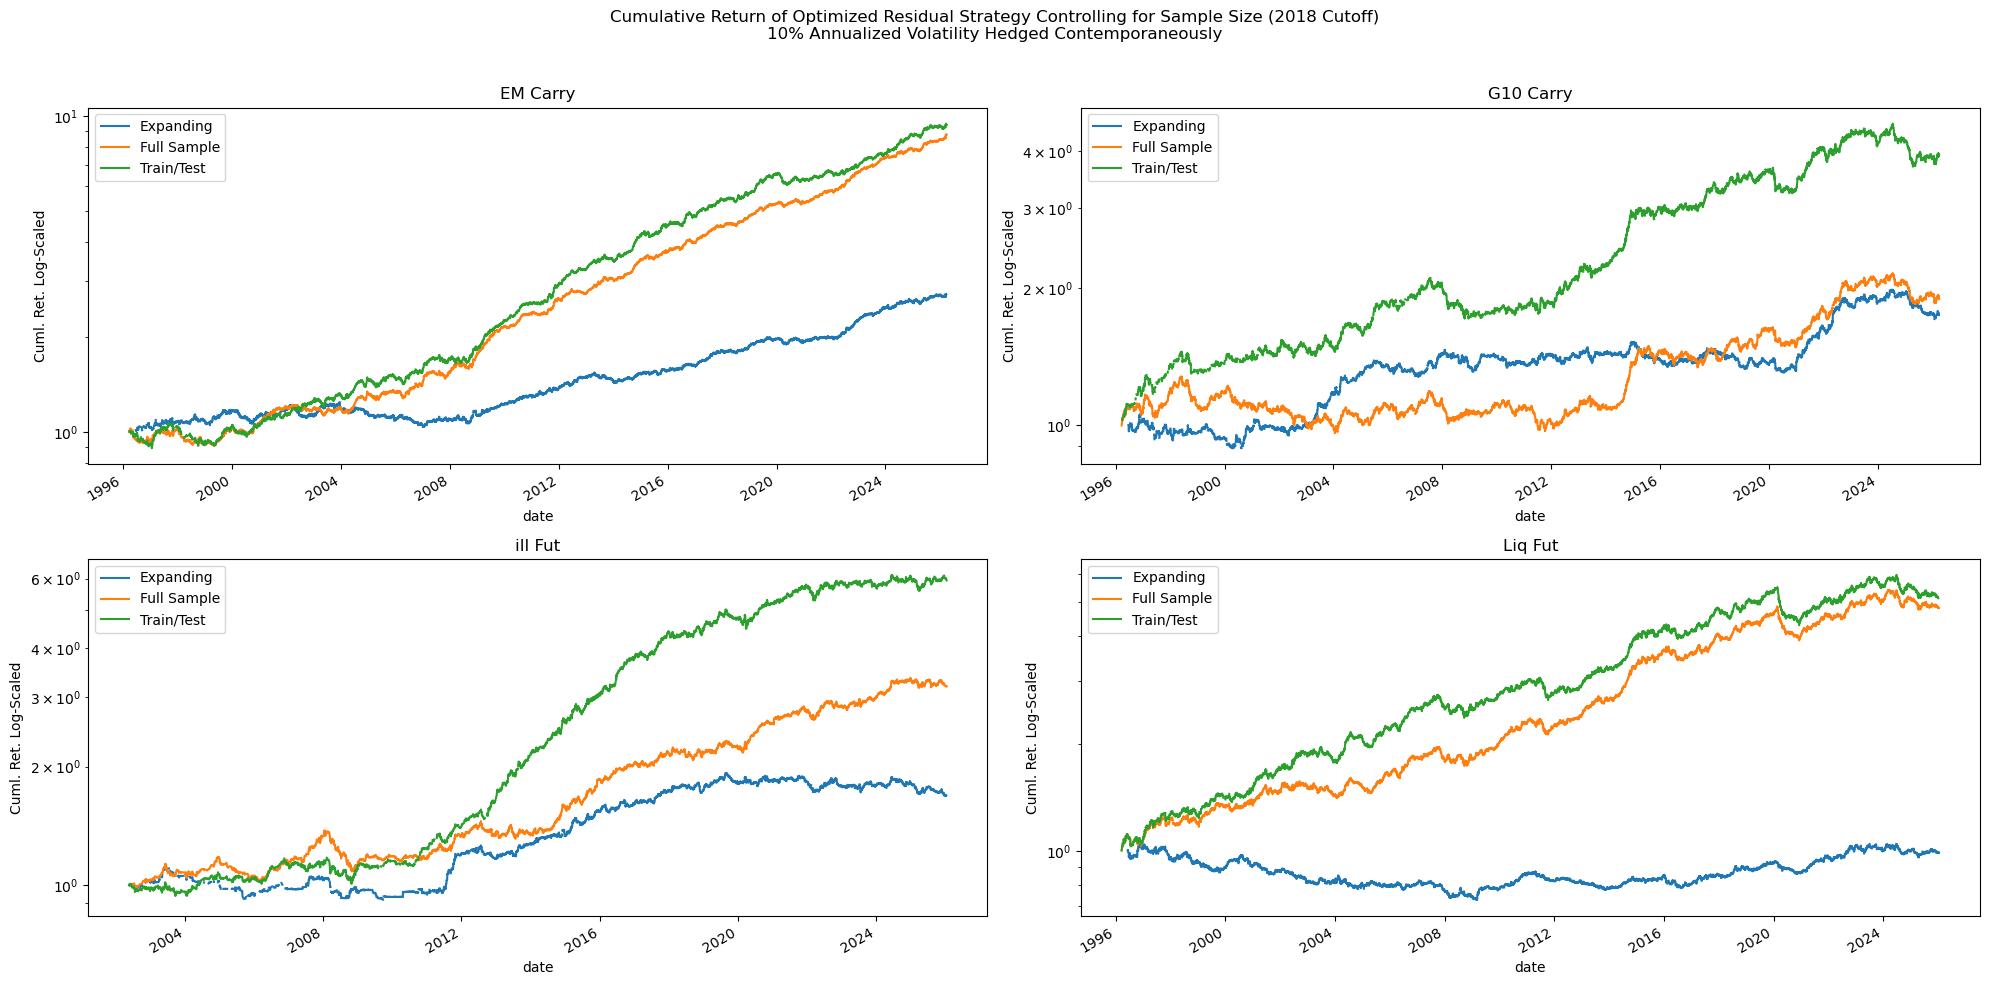

In [42]:
df_plot = (df_opt_resid_group
    .loc[lambda x: x.variable == "vol_rtn"]
    .drop(columns = ["variable"]))

groups = df_plot.group.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

for group, ax in zip(groups, axes.flatten()):

    (df_plot
        .loc[lambda x: x.group == group]
        .rename(columns = {"optimization": ""})
        .pivot(index = "date", columns = "", values = "value")
        .rename(columns = renamer)
        .apply(lambda x: np.cumprod(1 + x))
        .plot(
            title  = renamer[group],
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Cumulative Return of Optimized Residual Strategy Controlling for Sample Size (2018 Cutoff)\n10% Annualized Volatility Hedged Contemporaneously\n\n")
plt.tight_layout()
plt.show()

In [65]:
display(df_opt_resid_group
    .drop(columns = ["date"])
    .groupby(["optimization", "group", "variable"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(renamer)
    .rename(columns = {
        "group"       : "Group",
        "optimization": "",
        "variable"    : "Vol. Target"})
    .pivot(index = "Group", columns = ["", "Vol. Target"], values = "value"))

Expanding           Full Sample           Train/Test          
Vol. Target    Lagged   Perfect      Lagged   Perfect     Lagged   Perfect
Group                                                                     
EM Carry     0.758512  0.862331    1.307270  1.406746   1.240746  1.347430
G10 Carry    0.383002  0.426889    0.379392  0.371692   0.759736  0.817982
Liq Fut      0.043512  0.019329    0.812885  0.858741   0.777125  0.894948
ill Fut      0.469500  0.552246    0.847860  0.880956   1.291812  1.368290

In [44]:
df_opt_port = (df_opt_resid
    .melt(id_vars = ["date", "optimization", "fx_ticker", "group"])
    .dropna()
    .drop(columns = ["fx_ticker", "group"])
    .groupby(["date", "variable", "optimization"])
    .agg("mean")
    .reset_index())

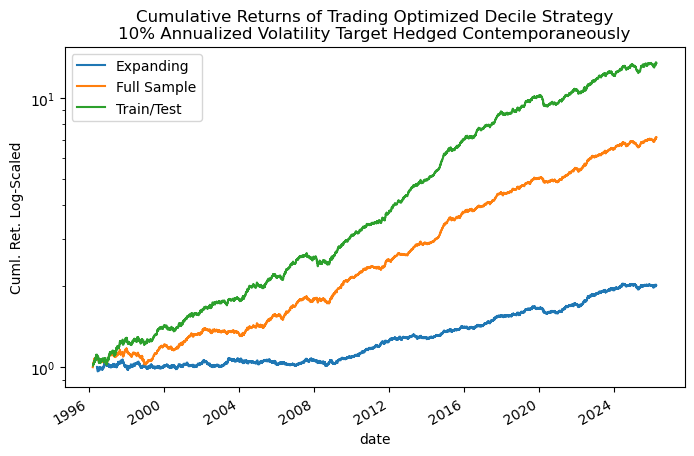

In [67]:
fig, axes = plt.subplots(figsize = (8,5))

(df_opt_port
    .loc[lambda x: x.variable == "vol_rtn"]
    .rename(columns = {"optimization": ""})
    .pivot(index = "date", columns = "", values = "value")
    .rename(columns = renamer)
    .apply(lambda x: np.cumprod(1 + x))
    .plot(
        ax     = axes,
        logy   = True,
        ylabel = "Cuml. Ret. Log-Scaled",
        title  = "Cumulative Returns of Trading Optimized Decile Strategy\n10% Annualized Volatility Target Hedged Contemporaneously"))

#fig.savefig(os.path.join(pic_path, "OptResidBacktest.jpeg"), dpi = 300)
plt.show()

In [70]:
display(df_opt_port
    .drop(columns = ["date"])
    .groupby(["variable", "optimization"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(renamer)
    .rename(columns = {
        "optimization": "",
        "variable"    : "Vol. Target"})
    .pivot(index = "", columns = "Vol. Target", values = "value"))

Vol. Target,Lagged,Perfect
,,
Expanding,0.743806,0.793899
Full Sample,1.407898,1.477136
Train/Test,1.519760,1.660939


# Combining Everything

In [47]:
df_for_tmp = (df_for_ports
    .loc[lambda x: x.variable == "vol_rtn"]
    .drop(columns = ["variable", "group"])
    .dropna()
    .groupby(["date", "regression"])
    .agg("mean")
    .rename(columns = {"value": "ols_forecasted"})
    .reset_index())

df_resid_tmp = (df_resid_port
    .loc[lambda x: x.variable == "vol_rtn"]
    .drop(columns = ["group", "variable"])
    .dropna()
    .groupby(["date", "regression"])
    .agg("mean")
    .rename(columns = {"value": "ols_resid"})
    .reset_index())

In [48]:
df_opt_resid_tmp = (df_opt_resid
    .drop(columns = ["lag_vol_rtn", "fx_ticker", "group"])
    .dropna()
    .groupby(["date", "optimization"])
    .agg("mean")
    .reset_index()
    .replace({"in_sample": "full_sample"})
    .rename(columns = {
        "vol_rtn"     : "opt_resid",
        "optimization": "regression"}))

In [49]:
df_opt_trend_tmp = (df_opt_trend
    [["date", "optimization", "vol_rtn"]]
    .groupby(["date", "optimization"])
    .agg("mean")
    .reset_index()
    .replace({"in_sample": "full_sample"})
    .rename(columns = {
        "vol_rtn"     : "opt_trend",
        "optimization": "regression"}))

In [50]:
df_combined = (df_for_tmp
    .merge(right = df_resid_tmp,     how = "inner", on = ["date", "regression"])
    .merge(right = df_opt_resid_tmp, how = "inner", on = ["date", "regression"])
    .merge(right = df_opt_trend_tmp, how = "inner", on = ["date", "regression"])
    .set_index("date"))

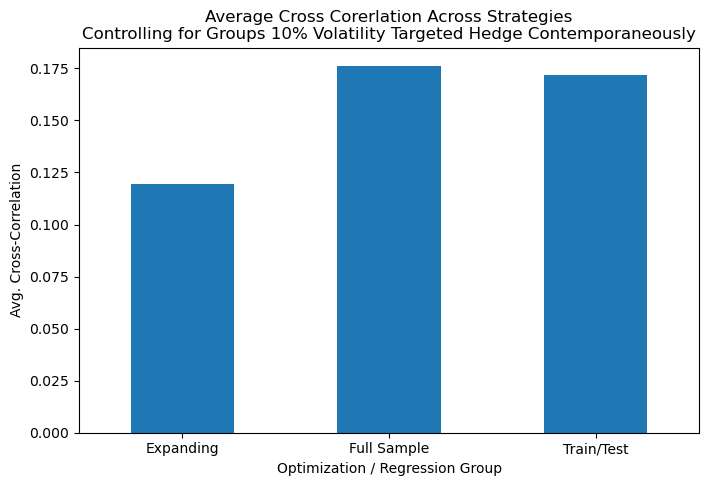

In [71]:
fig, axes = plt.subplots(figsize = (8,5))

(df_combined
    .reset_index(drop = True)
    .groupby("regression")
    .agg("corr")
    .reset_index()
    .melt(id_vars = ["regression", "level_1"])
    .loc[lambda x: x.level_1 != x.variable]
    [["regression", "value"]]
    .groupby("regression")
    .agg("mean")
    .reset_index()
    .replace(renamer)
    .set_index("regression")
    .plot(
        ax     = axes,
        kind   = "bar",
        xlabel = "Optimization / Regression Group",
        rot    = 0,
        legend = False,
        ylabel = "Avg. Cross-Correlation",
        title  = "Average Cross Corerlation Across Strategies\nControlling for Groups 10% Volatility Targeted Hedge Contemporaneously"))

fig.savefig(os.path.join(pic_path, "AvgCrossCorrelation.jpeg"), dpi = 300)
plt.show()

In [74]:
display(df_combined
    .reset_index()
    .set_index(["date", "regression"])
    .assign(avg = lambda x: x.mean(axis = 1))
    .reset_index()
    .melt(id_vars = ["date", "regression"])
    .drop(columns = ["date"])
    .groupby(["regression", "variable"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(renamer)
    .rename(columns = {
        "variable"  : "",
        "regression": "Regression"})
    .pivot(index = "Regression", columns = "", values = "value"))

,Average,OLS For,OLS Resid,Opt Resid,Opt Trend
Regression,,,,,
Expanding,1.776109,1.415770,0.690477,0.810683,1.433456
Full Sample,2.304780,1.853867,0.501228,1.477136,1.987076
Train/Test,2.457889,2.245111,0.508734,1.660939,1.905866
